# Chapter 2, Example 1: From Local Factors to a Global Probability Distribution

This notebook develops the smallest nontrivial example that will be reused throughout the book. Four binary variables are coupled through local factors arranged on a chain. Because there are only $2^4=16$ configurations, every quantity can be computed exactly by enumeration.

The example illustrates the five recurring computational tasks of the book:

1. **Representation:** express a global distribution as a product of local factors.
2. **Inference:** compute marginals, correlations, and expectations.
3. **Optimization:** identify the most probable configuration.
4. **Learning preview:** study how observables respond to a factor parameter.
5. **Generation:** draw exact samples from the normalized distribution.

The notebook also creates figures in the book-level `figs/` directory. Every figure is saved in both PDF and PNG formats so that it can be reused in the manuscript, lecture notes, or slides.

## 1. Mathematical model

Let

$$
x_i\in\{-1,+1\},\qquad i=1,2,3,4.
$$

We define an unnormalized weight

$$
w(\boldsymbol{x})
=
f_1(x_1)
f_{12}(x_1,x_2)
f_{23}(x_2,x_3)
f_{34}(x_3,x_4)
f_4(x_4),
$$

with local factors

$$
f_1(x_1)=\exp(h_1x_1),\qquad
f_4(x_4)=\exp(h_4x_4),
$$

and

$$
f_{ij}(x_i,x_j)=\exp(J_{ij}x_ix_j).
$$

The normalized probability distribution is

$$
p(\boldsymbol{x})=\frac{w(\boldsymbol{x})}{Z},
\qquad
Z=\sum_{\boldsymbol{x}\in\{-1,+1\}^4}w(\boldsymbol{x}).
$$

This is a pairwise binary graphical model. It is also a four-spin Ising chain with boundary fields, but the main purpose here is more general: to see how local factors define a global probability distribution.

The chosen parameters include both attractive and repulsive interactions. Positive $J_{ij}$ favors equal neighboring spins, while negative $J_{ij}$ favors opposite neighboring spins.

In [1]:
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Publication-oriented typography shared by all Chapter 2 figures.
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
    "lines.linewidth": 2.0,
})

# Locate notebooks/ch02 whether the notebook is launched from this directory
# or from the root of the book repository.
CWD = Path.cwd()
if CWD.name == "ch02":
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / "ch02").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / "ch02"
else:
    NOTEBOOK_DIR = CWD

FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Reproducible pseudo-random samples.
RNG = np.random.default_rng(577)

# Parameters of the four-variable chain.
PARAMS = {
    "h1": 0.35,
    "J12": 0.90,
    "J23": -0.65,
    "J34": 0.75,
    "h4": -0.25,
}

PARAMS

# Larger typography is used because several figures are reused in the book.
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})

## 2. A helper for publication-quality figures

The function below saves each figure twice:

- PDF for vector graphics in the book;
- PNG for notebooks, web pages, and slides.

The notebook uses descriptive filenames beginning with `ch02_01_`, which identifies Chapter 2, Example 1.

In [2]:
def save_figure(fig, stem: str) -> None:
    """Save a Matplotlib figure as both PDF and PNG."""
    pdf_path = FIG_DIR / f"{stem}.pdf"
    png_path = FIG_DIR / f"{stem}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=220, bbox_inches="tight")
    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")

## 3. The factor graph

A factor graph is bipartite:

- circular nodes represent variables;
- square nodes represent factors;
- an edge connects a factor to every variable on which that factor depends.

The graph displays local dependence without listing the full table of $16$ global weights.

Saved: figs/ch02_01_factor_graph.pdf
Saved: figs/ch02_01_factor_graph.png


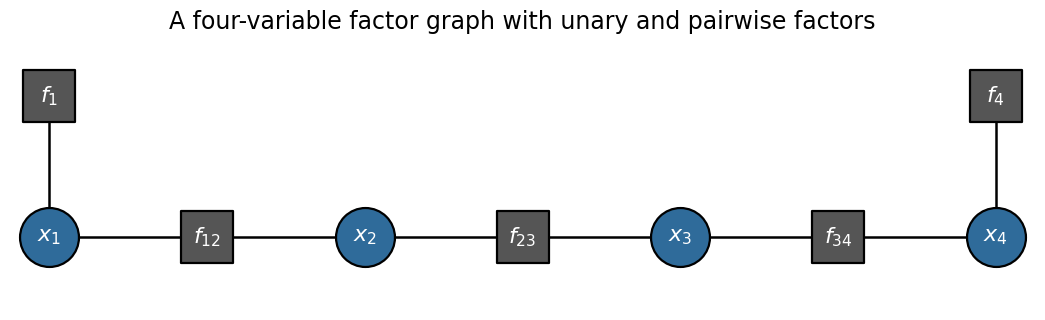

In [3]:
G = nx.Graph()
variable_nodes = ["x1", "x2", "x3", "x4"]
factor_nodes = ["f1", "f12", "f23", "f34", "f4"]
G.add_nodes_from(variable_nodes, kind="variable")
G.add_nodes_from(factor_nodes, kind="factor")
G.add_edges_from([
    ("f1", "x1"),
    ("f12", "x1"), ("f12", "x2"),
    ("f23", "x2"), ("f23", "x3"),
    ("f34", "x3"), ("f34", "x4"),
    ("f4", "x4"),
])

positions = {
    "x1": (0.0, 0.0), "f12": (1.2, 0.0),
    "x2": (2.4, 0.0), "f23": (3.6, 0.0),
    "x3": (4.8, 0.0), "f34": (6.0, 0.0),
    "x4": (7.2, 0.0),
    "f1": (0.0, 1.25), "f4": (7.2, 1.25),
}
labels = {
    "x1": r"$x_1$", "x2": r"$x_2$", "x3": r"$x_3$", "x4": r"$x_4$",
    "f1": r"$f_1$", "f12": r"$f_{12}$", "f23": r"$f_{23}$",
    "f34": r"$f_{34}$", "f4": r"$f_4$",
}

fig, ax = plt.subplots(figsize=(10.5, 3.25))
nx.draw_networkx_edges(G, positions, ax=ax, width=1.8)
nx.draw_networkx_nodes(
    G, positions, nodelist=variable_nodes, node_shape="o",
    node_size=1800, node_color="#2F6B9A", edgecolors="black", linewidths=1.6, ax=ax
)
nx.draw_networkx_nodes(
    G, positions, nodelist=factor_nodes, node_shape="s",
    node_size=1350, node_color="#555555", edgecolors="black", linewidths=1.6, ax=ax
)
nx.draw_networkx_labels(G, positions, labels=labels, font_size=16, font_color="white", ax=ax)
ax.set_title("A four-variable factor graph with unary and pairwise factors", pad=8)
# Reserve a little more space below the chain so the graph sits higher when
# the exported panel is aligned with a neighboring plot in the book.
ax.set_xlim(-0.30, 7.50)
ax.set_ylim(-0.65, 1.75)
ax.set_axis_off()
fig.tight_layout(pad=0.6)
save_figure(fig, "ch02_01_factor_graph")
plt.show()

## 4. Exact enumeration

For this small model, brute-force enumeration is the cleanest baseline. The procedure is:

1. list all $16$ configurations;
2. evaluate every local factor;
3. multiply the factors to obtain $w(\boldsymbol{x})$;
4. sum the weights to obtain $Z$;
5. divide by $Z$ to obtain $p(\boldsymbol{x})$.

This procedure is exact, but its cost grows exponentially with the number of variables. Later chapters replace brute-force enumeration by message passing, variational approximations, Monte Carlo methods, tensor-network contractions, and learned generative mechanisms.

In [4]:
def local_factors(x, params=PARAMS):
    """Return all local factors for one spin configuration."""
    x1, x2, x3, x4 = x
    return {
        "f1": np.exp(params["h1"] * x1),
        "f12": np.exp(params["J12"] * x1 * x2),
        "f23": np.exp(params["J23"] * x2 * x3),
        "f34": np.exp(params["J34"] * x3 * x4),
        "f4": np.exp(params["h4"] * x4),
    }


def unnormalized_weight(x, params=PARAMS):
    factors = local_factors(x, params)
    return float(np.prod(list(factors.values())))


def configuration_label(x):
    return "".join("+" if value == 1 else "−" for value in x)


configurations = np.array(list(product([-1, 1], repeat=4)), dtype=int)
weights = np.array([unnormalized_weight(x) for x in configurations])
Z = weights.sum()
probabilities = weights / Z

rows = []
for x, weight, probability in zip(configurations, weights, probabilities):
    factors = local_factors(x)
    rows.append({
        "state": configuration_label(x),
        "x1": x[0], "x2": x[1], "x3": x[2], "x4": x[3],
        **factors,
        "weight": weight,
        "probability": probability,
    })

distribution = pd.DataFrame(rows)
distribution

,state,x1,x2,x3,x4,f1,f12,f23,f34,f4,weight,probability
0,−−−−,-1,-1,-1,-1,0.704688,2.459603,0.522046,2.117000,1.284025,2.459603,0.060767
1,−−−+,-1,-1,-1,1,0.704688,2.459603,0.522046,0.472367,0.778801,0.332871,0.008224
2,−−+−,-1,-1,1,-1,0.704688,2.459603,1.915541,0.472367,1.284025,2.013753,0.049751
3,−−++,-1,-1,1,1,0.704688,2.459603,1.915541,2.117000,0.778801,5.473947,0.135238
4,−+−−,-1,1,-1,-1,0.704688,0.406570,1.915541,2.117000,1.284025,1.491825,0.036857
5,−+−+,-1,1,-1,1,0.704688,0.406570,1.915541,0.472367,0.778801,0.201897,0.004988
6,−++−,-1,1,1,-1,0.704688,0.406570,0.522046,0.472367,1.284025,0.090718,0.002241
7,−+++,-1,1,1,1,0.704688,0.406570,0.522046,2.117000,0.778801,0.246597,0.006092
8,+−−−,1,-1,-1,-1,1.419068,0.406570,0.522046,2.117000,1.284025,0.818731,0.020227
9,+−−+,1,-1,-1,1,1.419068,0.406570,0.522046,0.472367,0.778801,0.110803,0.002737


The partition function is the sum of all unnormalized weights. It is not an arbitrary constant: it depends on every factor parameter and ensures that the probabilities sum to one.

In [5]:
print(f"Partition function Z = {Z:.8f}")
print(f"Sum of normalized probabilities = {probabilities.sum():.12f}")

assert Z > 0.0
assert np.isclose(probabilities.sum(), 1.0)
assert np.all(probabilities > 0.0)

Partition function Z = 40.47626861
Sum of normalized probabilities = 1.000000000000


## 5. Which configurations are probable?

The complete distribution can be visualized because there are only $16$ states. The labels use `+` for $+1$ and `−` for $-1$. For example, `+−−+` denotes

$$
(x_1,x_2,x_3,x_4)=(+1,-1,-1,+1).
$$

The mixed signs of the couplings create a nontrivial competition:

- $J_{12}>0$ favors $x_1=x_2$;
- $J_{23}<0$ favors $x_2=-x_3$;
- $J_{34}>0$ favors $x_3=x_4$;
- the fields $h_1$ and $h_4$ bias the boundary variables.

Saved: figs/ch02_01_configuration_probabilities.pdf
Saved: figs/ch02_01_configuration_probabilities.png


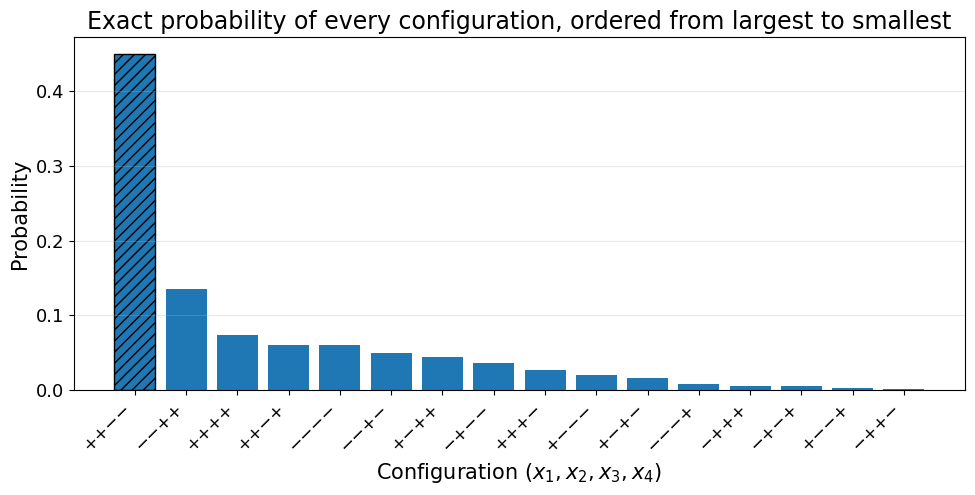

Five most probable configurations:


,state,weight,probability
0,++−−,18.174145,0.449007
1,−−++,5.473947,0.135238
2,++++,3.004166,0.074220
3,++−+,2.459603,0.060767
4,−−−−,2.459603,0.060767


In [6]:
order = np.argsort(probabilities)[::-1]
ordered_labels = [configuration_label(configurations[i]) for i in order]
ordered_probabilities = probabilities[order]

fig, ax = plt.subplots(figsize=(10, 5.2))
bars = ax.bar(np.arange(len(order)), ordered_probabilities)
ax.set_xticks(np.arange(len(order)))
ax.set_xticklabels(ordered_labels, rotation=45, ha="right")
ax.set_ylabel("Probability")
ax.set_xlabel(r"Configuration $(x_1,x_2,x_3,x_4)$")
ax.set_title("Exact probability of every configuration, ordered from largest to smallest")
ax.grid(axis="y", alpha=0.3)

# Mark the MAP bar by hatching rather than relying only on color.
bars[0].set_hatch("///")
bars[0].set_edgecolor("black")
fig.tight_layout()
save_figure(fig, "ch02_01_configuration_probabilities")
plt.show()

print("Five most probable configurations:")
distribution.iloc[order][["state", "weight", "probability"]].head(5).reset_index(drop=True)

## 6. Inference: marginals and expectations

A one-variable marginal is obtained by summing over all other variables:

$$
p_i(x_i)
=
\sum_{\boldsymbol{x}_{\setminus i}}p(\boldsymbol{x}).
$$

For spins taking values in $\{-1,+1\}$, the mean

$$
m_i=\mathbb{E}[x_i]
$$

is called the magnetization. It is related to the marginal by

$$
p_i(x_i=+1)=\frac{1+m_i}{2},
\qquad
p_i(x_i=-1)=\frac{1-m_i}{2}.
$$

Pairwise expectations

$$
\mathbb{E}[x_ix_j]
$$

measure alignment, while the connected covariance

$$
\operatorname{Cov}(x_i,x_j)
=
\mathbb{E}[x_ix_j]
-
\mathbb{E}[x_i]\mathbb{E}[x_j]
$$

removes the contribution of the individual means.

In [7]:
means = probabilities @ configurations
second_moments = np.einsum("n,ni,nj->ij", probabilities, configurations, configurations)
covariance = second_moments - np.outer(means, means)

marginal_plus = (1.0 + means) / 2.0
marginal_minus = (1.0 - means) / 2.0

marginal_table = pd.DataFrame({
    "variable": [r"x1", r"x2", r"x3", r"x4"],
    "P(x_i=-1)": marginal_minus,
    "P(x_i=+1)": marginal_plus,
    "E[x_i]": means,
})
marginal_table

,variable,P(x_i=-1),P(x_i=+1),E[x_i]
0,x1,0.304159,0.695841,0.391683
1,x2,0.338523,0.661477,0.322954
2,x3,0.643574,0.356426,-0.287148
3,x4,0.662716,0.337284,-0.325432


Saved: figs/ch02_01_single_variable_marginals.pdf
Saved: figs/ch02_01_single_variable_marginals.png


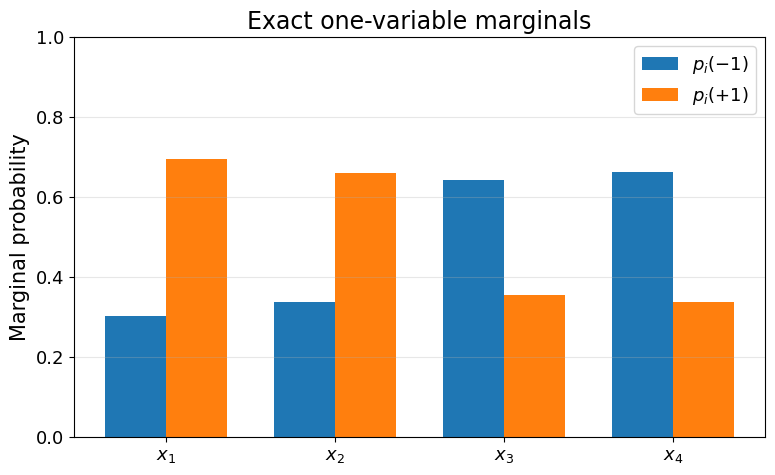

In [8]:
indices = np.arange(4)
width = 0.36

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(indices - width / 2, marginal_minus, width, label=r"$p_i(-1)$")
ax.bar(indices + width / 2, marginal_plus, width, label=r"$p_i(+1)$")
ax.set_xticks(indices)
ax.set_xticklabels([r"$x_1$", r"$x_2$", r"$x_3$", r"$x_4$"])
ax.set_ylim(0.0, 1.0)
ax.set_ylabel("Marginal probability")
ax.set_title("Exact one-variable marginals")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
save_figure(fig, "ch02_01_single_variable_marginals")
plt.show()

Saved: figs/ch02_01_correlation_matrix.pdf
Saved: figs/ch02_01_correlation_matrix.png


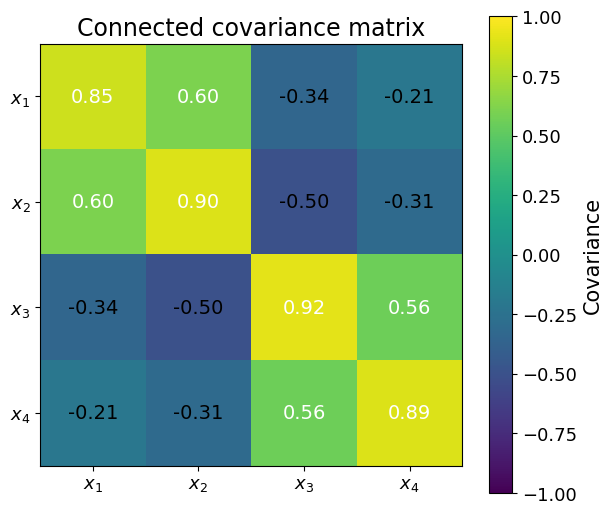

In [9]:
fig, ax = plt.subplots(figsize=(6.4, 5.5))
image = ax.imshow(covariance, vmin=-1.0, vmax=1.0)
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels([r"$x_1$", r"$x_2$", r"$x_3$", r"$x_4$"])
ax.set_yticklabels([r"$x_1$", r"$x_2$", r"$x_3$", r"$x_4$"])
ax.set_title("Connected covariance matrix")

for i in range(4):
    for j in range(4):
        value = covariance[i, j]
        text_color = "white" if abs(value) > 0.52 else "black"
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=14)

fig.colorbar(image, ax=ax, label="Covariance")
fig.tight_layout()
save_figure(fig, "ch02_01_correlation_matrix")
plt.show()

The graph is a chain, but variables that are not adjacent can still be statistically correlated. Graphical locality does **not** mean that distant variables are independent. Instead, the graph describes how dependence is assembled from local factors and which conditional independences may hold.

## 7. Optimization: the MAP configuration

The maximum a posteriori configuration is

$$
\boldsymbol{x}^{\mathrm{MAP}}
\in
\operatorname*{arg\,max}_{\boldsymbol{x}}p(\boldsymbol{x}).
$$

Because $Z$ is independent of $\boldsymbol{x}$, the same configuration maximizes the unnormalized weight:

$$
\operatorname*{arg\,max}_{\boldsymbol{x}}p(\boldsymbol{x})
=
\operatorname*{arg\,max}_{\boldsymbol{x}}w(\boldsymbol{x}).
$$

This simple observation is important: optimization can often avoid computing the partition function, even when probabilistic inference cannot.

In [10]:
map_index = int(np.argmax(probabilities))
map_configuration = configurations[map_index]
map_probability = probabilities[map_index]

print(f"MAP configuration: {configuration_label(map_configuration)}")
print(f"MAP spin vector: {tuple(map_configuration)}")
print(f"MAP probability: {map_probability:.6f}")

MAP configuration: ++−−
MAP spin vector: (np.int64(1), np.int64(1), np.int64(-1), np.int64(-1))
MAP probability: 0.449007


## 8. Generation: exact sampling

Once all probabilities are known, exact generation is straightforward: select one of the $16$ configurations with probabilities $p(\boldsymbol{x})$.

This is not a scalable method for large systems because it requires complete enumeration. Nevertheless, it provides an exact reference against which later samplers can be tested.

In [11]:
number_of_samples = 20_000
sample_indices = RNG.choice(len(configurations), size=number_of_samples, p=probabilities)
samples = configurations[sample_indices]
empirical_counts = np.bincount(sample_indices, minlength=len(configurations))
empirical_probabilities = empirical_counts / number_of_samples

maximum_error = np.max(np.abs(empirical_probabilities - probabilities))
print(f"Number of samples: {number_of_samples:,}")
print(f"Maximum absolute probability error: {maximum_error:.5f}")

Number of samples: 20,000
Maximum absolute probability error: 0.00389


Saved: figs/ch02_01_exact_sampling_check.pdf
Saved: figs/ch02_01_exact_sampling_check.png


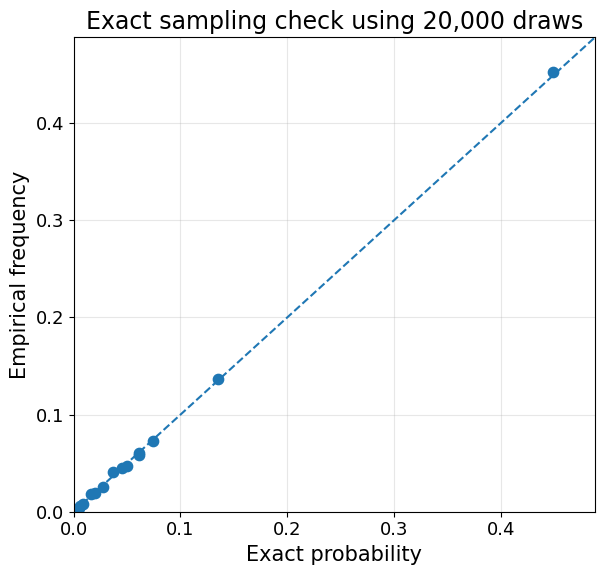

In [12]:
fig, ax = plt.subplots(figsize=(6.3, 6.0))
ax.scatter(probabilities, empirical_probabilities, s=55)
upper = max(probabilities.max(), empirical_probabilities.max()) * 1.08
ax.plot([0.0, upper], [0.0, upper], linestyle="--", linewidth=1.5)
ax.set_xlim(0.0, upper)
ax.set_ylim(0.0, upper)
ax.set_xlabel("Exact probability")
ax.set_ylabel("Empirical frequency")
ax.set_title(f"Exact sampling check using {number_of_samples:,} draws")
ax.grid(alpha=0.3)
fig.tight_layout()
save_figure(fig, "ch02_01_exact_sampling_check")
plt.show()

## 9. A learning preview: derivatives of the partition function

The partition function contains information about the moments of the model. For example,

$$
\frac{\partial\log Z}{\partial J_{23}}
=
\mathbb{E}[x_2x_3].
$$

This identity is central in statistical mechanics and parameter learning. It says that differentiating the global normalization with respect to a local interaction returns the corresponding sufficient statistic.

We verify the identity numerically while varying $J_{23}$ and keeping all other parameters fixed.

In [13]:
def exact_distribution(params):
    local_weights = np.array([unnormalized_weight(x, params) for x in configurations])
    local_Z = local_weights.sum()
    return local_Z, local_weights / local_Z


def log_partition(j23_value):
    params = dict(PARAMS)
    params["J23"] = float(j23_value)
    local_Z, _ = exact_distribution(params)
    return np.log(local_Z)


j23_grid = np.linspace(-1.6, 1.6, 121)
correlation_23 = []
for j23 in j23_grid:
    params = dict(PARAMS)
    params["J23"] = float(j23)
    _, local_probabilities = exact_distribution(params)
    correlation_23.append(
        np.sum(local_probabilities * configurations[:, 1] * configurations[:, 2])
    )
correlation_23 = np.array(correlation_23)

step = 1.0e-5
finite_difference = np.array([
    (log_partition(j23 + step) - log_partition(j23 - step)) / (2.0 * step)
    for j23 in j23_grid
])

assert np.max(np.abs(correlation_23 - finite_difference)) < 1.0e-8

Saved: figs/ch02_01_coupling_sensitivity.pdf
Saved: figs/ch02_01_coupling_sensitivity.png


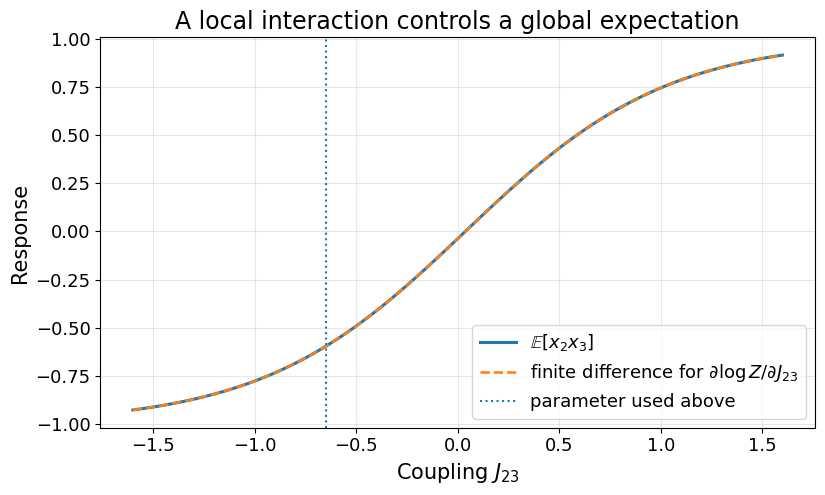

Maximum discrepancy between the expectation and the numerical derivative: 4.602e-11


In [14]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.plot(j23_grid, correlation_23, linewidth=2.2, label=r"$\mathbb{E}[x_2x_3]$")
ax.plot(
    j23_grid,
    finite_difference,
    linestyle="--",
    linewidth=1.8,
    label=r"finite difference for $\partial\log Z/\partial J_{23}$",
)
ax.axvline(PARAMS["J23"], linestyle=":", linewidth=1.5, label="parameter used above")
ax.set_xlabel(r"Coupling $J_{23}$")
ax.set_ylabel("Response")
ax.set_title("A local interaction controls a global expectation")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
save_figure(fig, "ch02_01_coupling_sensitivity")
plt.show()

print(
    "Maximum discrepancy between the expectation and the numerical derivative: "
    f"{np.max(np.abs(correlation_23 - finite_difference)):.3e}"
)

## 10. Computational scaling

For $n$ binary variables, brute-force enumeration requires evaluating $2^n$ configurations. The table below shows how quickly the state space grows.

The purpose of graphical-model algorithms is not simply to draw a graph. Their purpose is to exploit locality, topology, symmetry, low-rank structure, stochasticity, or approximation so that useful quantities can be computed without enumerating the entire state space.

In [15]:
scaling = pd.DataFrame({
    "number of binary variables n": [4, 10, 20, 30, 40, 50],
    "number of configurations 2^n": [2**n for n in [4, 10, 20, 30, 40, 50]],
})
scaling

,number of binary variables n,number of configurations 2^n
0,4,16
1,10,1024
2,20,1048576
3,30,1073741824
4,40,1099511627776
5,50,1125899906842624


## 11. Exercises

The exercises are designed to reuse the notebook rather than require a separate implementation.

### Exercise 1: Change one interaction

Replace $J_{23}=-0.65$ by $J_{23}=+0.65$.

1. Recompute the distribution and the MAP configuration.
2. Explain which local preference changed.
3. Compare $\mathbb{E}[x_2x_3]$ before and after the modification.
4. Identify which figure changes most visibly.

### Exercise 2: Add a hard constraint

Replace the factor $f_{23}$ by

$$
f_{23}^{\mathrm{hard}}(x_2,x_3)
=
\begin{cases}
1, & x_2x_3=-1,\\
0, & x_2x_3=+1.
\end{cases}
$$

1. Which configurations are removed from the support?
2. Does the partition function remain positive?
3. How should the positivity assumption used in some later graphical-model theorems be reconsidered?

### Exercise 3: Verify a response identity

Show numerically that

$$
\frac{\partial\log Z}{\partial h_1}
=
\mathbb{E}[x_1].
$$

Use both exact expectations and a centered finite difference.

### Exercise 4: Close the chain into a loop

Add a factor

$$
f_{41}(x_4,x_1)=\exp(J_{41}x_4x_1).
$$

1. Draw the new factor graph.
2. Recompute $Z$ and the marginals.
3. Explain why exact enumeration is unaffected for four variables, while the topology matters greatly for message passing and loop corrections.

### Exercise 5: Compare optimization and inference

Multiply every weight by the same positive constant $c$.

1. What happens to $Z$?
2. What happens to $p(\boldsymbol{x})$?
3. What happens to the MAP configuration?
4. Which computational tasks require normalization and which do not?

### Exercise 6: Parameter estimation from generated data

Generate samples using a hidden value of $J_{23}$. Keeping all other parameters fixed, evaluate the average log-likelihood on a grid of candidate values.

1. Does the likelihood peak near the generating value?
2. How does the estimate change with sample size?
3. Relate the likelihood derivative to empirical and model expectations of $x_2x_3$.

## 12. Main lessons

This example establishes a pattern that will recur throughout the book:

- a global distribution is assembled from local factors;
- the partition function turns local weights into a probability distribution;
- inference sums over configurations;
- optimization searches over configurations;
- generation samples configurations;
- derivatives of $\log Z$ connect local parameters to global expectations;
- exact enumeration provides a trustworthy baseline but scales exponentially.

The same four-variable model can later be revisited to introduce exact belief propagation on a chain, Monte Carlo sampling, variational approximations, parameter learning, tensor contraction, and loop corrections after adding the closing edge.